# t-SNE — Modelos Aumentados (1920reprueba + 2021)

Visualización de embeddings de alumnos OOT proyectados con el mejor proyector NN encontrado en la búsqueda de arquitecturas.

**Pipeline:**
1. Carga modelo TuckER augmentado `s2_ws4d_dataset_augmentado_1920reprueba_2021_s2_rdim{RDIM}`
2. Entrena proyector NN (`MLPFlexible` con la mejor config para el RDIM elegido) sobre alumnos del train (2019/2020/2021)
3. Para la cohorte OOT elegida: proyecta notas S1 → embedding y calcula vector de perfil relacional `W × e_alumno × e_curso`
4. t-SNE sobre esos vectores, coloreado por aprueba/reprueba y por nota

In [1]:
# ============================================================
# CONFIGURACIÓN — cambiar aquí para probar distintos modelos
# ============================================================
RDIM = 8   # 5 o 8

# Cohorte OOT a visualizar: (20221, 20222) o (20231, 20232)
COHORTE_OOT = ("20231", "20232")

# Cursos a visualizar (S2)
CURSOS_A_VISUALIZAR = ["CC1002", "FI1100", "MA1002", "MA1102"]

# Mejores arquitecturas por rdim (de busqueda_nn_rdim_top)
#   rdim=5: drop05      → hidden=[64, 128],    dropout=0.5, lr=1e-3, act="relu"  (F1_avg=0.3985)
#   rdim=8: deep_small  → hidden=[32, 64, 32], dropout=0.2, lr=1e-3, act="relu"  (F1_avg=0.4023)
NN_BEST_CONFIGS = {
    5: {"hidden": [64, 128],    "dropout": 0.5, "lr": 1e-3, "act": "relu"},
    8: {"hidden": [32, 64, 32], "dropout": 0.2, "lr": 1e-3, "act": "relu"},
}
NN_CFG = NN_BEST_CONFIGS[RDIM]

# Hiperparámetros de entrenamiento del proyector
SEED       = 42
MAX_EPOCHS = 500
PATIENCE   = 100

print(f"RDIM={RDIM} | OOT={COHORTE_OOT[0]}->{COHORTE_OOT[1]}")
print(f"NN config: hidden={NN_CFG['hidden']}, dropout={NN_CFG['dropout']}, lr={NN_CFG['lr']}, act={NN_CFG['act']}")

RDIM=8 | OOT=20231->20232
NN config: hidden=[32, 64, 32], dropout=0.2, lr=0.001, act=relu


In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Añadir raíz del repo al path para importar model.py y load_data.py
REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from model import TuckER
from load_data import Data

torch.manual_seed(SEED)
np.random.seed(SEED)

# Rutas principales
DATASET_NAME = "dataset_augmentado_1920reprueba_2021_s2"
DF_BASE      = REPO_ROOT / "data" / "dataframes_por_semestre"
RESULTS_DIR  = REPO_ROOT / "results"
OUTPUT_DIR   = RESULTS_DIR / f"tsne_augmentado_rdim{RDIM}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EDIM = 4  # dimensión de embeddings de entidad (fijo en todos los modelos)

CURSOS_S1 = ["BT1211", "FI1000", "MA1001", "MA1101"]
CURSOS_S2 = ["CC1002", "FI1100", "MA1002", "MA1102"]
CURSOS_PERMITIDOS = set(CURSOS_S1 + CURSOS_S2)

FAIL_GRADE        = 1.0
APPROVED_TRANSFER = 4.0

# Cohortes que están en el train del dataset aumentado
TRAIN_COHORTES = [("20191", "20192"), ("20201", "20202"), ("20211", "20212")]

print(f"Repo root : {REPO_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Repo root : C:\Users\LuisPlaza\MEMORIA\tucker_pull
Output dir: C:\Users\LuisPlaza\MEMORIA\tucker_pull\results\tsne_augmentado_rdim8


In [3]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def _norm_cols(df):
    df = df.copy()
    df["ID"]          = df["ID"].astype(str).str.strip().str.upper()
    df["CURSO"]       = df["CURSO"].astype(str).str.strip().str.upper()
    df["ESTADO_CURSO"] = df["ESTADO_CURSO"].astype(str)
    return df


def _nota_efectiva(estado, nota_raw):
    if "Aprobado (T)" in str(estado) or "Aprobado(T)" in str(estado):
        return APPROVED_TRANSFER
    try:
        return float(str(nota_raw).replace(",", "."))
    except Exception:
        if "Aprobado" in str(estado):
            return APPROVED_TRANSFER
        return FAIL_GRADE


def _normalizar(n):
    """Normaliza nota a [-1, 1]: (nota - 4.0) / 3.0"""
    if n is None or (isinstance(n, float) and pd.isna(n)):
        return (FAIL_GRADE - 4.0) / 3.0
    return (float(n) - 4.0) / 3.0


def _determinar_relacion(estado, nota_raw):
    e = str(estado)
    if "Aprobado" in e and "Eliminado" not in e and "Reprobado" not in e:
        return "aprueba"
    if "Reprobado" in e or "Eliminado" in e:
        return "reprueba"
    try:
        nota = float(str(nota_raw).replace(",", "."))
        return "reprueba" if nota < 4.0 else "aprueba"
    except Exception:
        return None


def construir_notas_s1(ids, sem_s1):
    """Devuelve dict {alumno: array 4D normalizado} con notas de S1."""
    ruta = DF_BASE / f"df_{sem_s1}.csv"
    if not ruta.exists():
        return {}
    df = _norm_cols(pd.read_csv(ruta, sep=";"))
    df = df[df["CURSO"].isin(CURSOS_S1)].copy()
    df["NOTA_EF"] = [
        _nota_efectiva(e, n)
        for e, n in zip(df["ESTADO_CURSO"], df["NOTA"])
    ]
    pivot = df.pivot_table(index="ID", columns="CURSO", values="NOTA_EF", aggfunc="max")
    pivot = pivot.reindex(columns=CURSOS_S1).fillna(FAIL_GRADE)
    result = {}
    for alumno in ids:
        if alumno in pivot.index:
            row = pivot.loc[alumno]
            result[alumno] = np.array([_normalizar(row[c]) for c in CURSOS_S1], dtype=np.float32)
        else:
            result[alumno] = np.array([_normalizar(FAIL_GRADE)] * 4, dtype=np.float32)
    return result


def calcular_perfil_relacional(W, e_s, e_o):
    """
    Calcula v = W ×_2 e_s ×_3 e_o (perfil en espacio de relaciones).
    W : [rdim, edim, edim]
    e_s: [edim]  — embedding del alumno
    e_o: [edim]  — embedding del curso
    Retorna: [rdim]
    """
    # Contraer W con e_s sobre la dim 1 (primera edim del alumno)
    temp = torch.tensordot(W, e_s, dims=([1], [0]))   # [rdim, edim]
    # Contraer con e_o sobre la dim 1 (segunda edim del curso)
    v_perfil = torch.tensordot(temp, e_o, dims=([1], [0]))  # [rdim]
    return v_perfil.cpu().numpy()


print("Funciones auxiliares cargadas.")

Funciones auxiliares cargadas.


In [4]:
# ============================================================
# MLP FLEXIBLE (igual que en buscar_mejor_nn_rdim_top.py)
# ============================================================

class MLPFlexible(nn.Module):
    def __init__(self, input_dim, output_dim, hidden, dropout, act):
        super().__init__()
        act_map = {
            "relu":  nn.ReLU,
            "tanh":  nn.Tanh,
            "leaky": lambda: nn.LeakyReLU(0.1),
        }
        act_fn = act_map.get(act, nn.ReLU)
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), act_fn()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def entrenar_proyector(X, Y, cfg, edim, max_epochs=500, patience=100, seed=42):
    """Entrena MLPFlexible para mapear notas_S1 (4D) → embedding aprendido (edim)."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    modelo = MLPFlexible(4, edim, cfg["hidden"], cfg["dropout"], cfg["act"])
    n   = len(X)
    idx = np.random.permutation(n)
    n_tr = int(0.8  * n)
    n_va = int(0.15 * n)
    X_tr, Y_tr = X[idx[:n_tr]],          Y[idx[:n_tr]]
    X_va, Y_va = X[idx[n_tr:n_tr+n_va]], Y[idx[n_tr:n_tr+n_va]]

    loader  = DataLoader(TensorDataset(X_tr, Y_tr), batch_size=64, shuffle=True)
    opt     = torch.optim.Adam(modelo.parameters(), lr=cfg["lr"])
    loss_fn = nn.MSELoss()

    best_val   = float("inf")
    best_state = None
    no_improve = 0

    for ep in range(1, max_epochs + 1):
        modelo.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(modelo(xb), yb).backward()
            opt.step()
        modelo.eval()
        with torch.no_grad():
            val_loss = float(loss_fn(modelo(X_va), Y_va))
        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in modelo.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            print(f"  Early stopping en época {ep} (val_loss={best_val:.5f})")
            break
    else:
        print(f"  Completó {max_epochs} épocas (val_loss={best_val:.5f})")

    modelo.load_state_dict(best_state)
    modelo.eval()
    return modelo, best_val


print("MLPFlexible y función de entrenamiento definidas.")

MLPFlexible y función de entrenamiento definidas.


In [6]:

# ============================================================
# 1. CARGAR MODELO TUCKER
# ============================================================
model_folder = RESULTS_DIR / f"s2_ws4d_{DATASET_NAME}_rdim{RDIM}"
model_path   = model_folder / "best_model.pt"
# Data usa path relativo al CWD → usar path absoluto
data_dir     = str(REPO_ROOT / "data" / DATASET_NAME) + "/"

assert model_path.exists(), f"Modelo no encontrado: {model_path}"

d = Data(data_dir=data_dir, reverse=True)
tucker_model = TuckER(d, EDIM, RDIM, input_dropout=0.3, hidden_dropout1=0.4, hidden_dropout2=0.5)
state = torch.load(model_path, map_location="cpu", weights_only=True)
tucker_model.load_state_dict(state)
tucker_model.eval()

entity_idxs   = {e: i for i, e in enumerate(d.entities)}
relation_idxs = {r: i for i, r in enumerate(d.relations)}
W_tensor      = tucker_model.W.data  # [rdim, edim, edim]
E_tensor      = tucker_model.E.weight.data  # [n_entities, edim]

print(f"Modelo cargado: {model_path.name}")
print(f"  Entidades: {len(d.entities)}, Relaciones: {len(d.relations)}")
print(f"  W shape: {W_tensor.shape}, E shape: {E_tensor.shape}")

# ============================================================
# 2. PREPARAR DATOS DE ENTRENAMIENTO PARA EL PROYECTOR NN
# ============================================================
# Alumnos del KG (excluyendo cursos y entidades reverse)
alum_entities = [
    e for e in d.entities
    if e not in CURSOS_PERMITIDOS
    and not any(e == c + "_REVERSE" for c in CURSOS_PERMITIDOS)
]
print(f"\nAlumnos en el KG: {len(alum_entities)}")

# Notas S1 de todas las cohortes de train
notas_por_alumno = {}
for sem_s1, _ in TRAIN_COHORTES:
    notas = construir_notas_s1(alum_entities, sem_s1)
    notas_por_alumno.update(notas)
print(f"Alumnos con notas S1 encontrados: {len(notas_por_alumno)}")

# Construir X (notas normalizadas) e Y (embeddings aprendidos)
X_list, Y_list = [], []
for alumno in alum_entities:
    if alumno in notas_por_alumno and alumno in entity_idxs:
        idx = entity_idxs[alumno]
        X_list.append(notas_por_alumno[alumno])
        Y_list.append(E_tensor[idx].numpy())

X_train = torch.tensor(np.array(X_list), dtype=torch.float32)
Y_train = torch.tensor(np.array(Y_list), dtype=torch.float32)
print(f"Datos NN: X={X_train.shape}, Y={Y_train.shape}")

# ============================================================
# 3. ENTRENAR PROYECTOR NN
# ============================================================
print(f"\nEntrenando proyector NN con config: {NN_CFG}")
proyector, val_loss = entrenar_proyector(
    X_train, Y_train, NN_CFG, EDIM, MAX_EPOCHS, PATIENCE, SEED
)
print(f"Proyector entrenado. val_loss_final={val_loss:.5f}")


Modelo cargado: best_model.pt
  Entidades: 959, Relaciones: 4
  W shape: torch.Size([8, 4, 4]), E shape: torch.Size([959, 4])

Alumnos en el KG: 951
Alumnos con notas S1 encontrados: 951
Datos NN: X=torch.Size([951, 4]), Y=torch.Size([951, 4])

Entrenando proyector NN con config: {'hidden': [32, 64, 32], 'dropout': 0.2, 'lr': 0.001, 'act': 'relu'}
  Early stopping en época 295 (val_loss=0.02201)
Proyector entrenado. val_loss_final=0.02201


In [7]:
# ============================================================
# 4. PROYECTAR ALUMNOS OOT Y PREPARAR DATOS PARA t-SNE
# ============================================================
sem_s1_oot, sem_s2_oot = COHORTE_OOT
print(f"Cohorte OOT: {sem_s1_oot} → {sem_s2_oot}")

ruta_s1 = DF_BASE / f"df_{sem_s1_oot}.csv"
ruta_s2 = DF_BASE / f"df_{sem_s2_oot}.csv"
assert ruta_s1.exists() and ruta_s2.exists(), "Archivos de cohorte OOT no encontrados."

df_s1 = _norm_cols(pd.read_csv(ruta_s1, sep=";"))
df_s2 = _norm_cols(pd.read_csv(ruta_s2, sep=";"))

# Alumnos con los 4 cursos S1 completos
conteo     = df_s1[df_s1["CURSO"].isin(CURSOS_S1)].groupby("ID")["CURSO"].nunique()
ids_validos = set(conteo[conteo == 4].index)
print(f"Alumnos OOT con 4 cursos S1: {len(ids_validos)}")

# Notas S1 normalizadas para los alumnos OOT
notas_oot = construir_notas_s1(list(ids_validos), sem_s1_oot)

# Para cada alumno OOT, proyectar notas S1 → embedding
embeddings_oot = {}
with torch.no_grad():
    for alumno, notas_vec in notas_oot.items():
        x = torch.tensor(notas_vec, dtype=torch.float32).unsqueeze(0)
        e_h = proyector(x).squeeze(0)  # [edim]
        embeddings_oot[alumno] = e_h

print(f"Embeddings generados para {len(embeddings_oot)} alumnos OOT")

# Registros S2 de la cohorte OOT
df_s2_filt = df_s2[
    df_s2["ID"].isin(ids_validos) &
    df_s2["CURSO"].isin(CURSOS_A_VISUALIZAR)
].copy()

df_s2_filt["relacion"] = [
    _determinar_relacion(e, n)
    for e, n in zip(df_s2_filt["ESTADO_CURSO"], df_s2_filt["NOTA"])
]
df_s2_filt = df_s2_filt.dropna(subset=["relacion"])
df_s2_filt["nota_num"] = [
    _nota_efectiva(e, n)
    for e, n in zip(df_s2_filt["ESTADO_CURSO"], df_s2_filt["NOTA"])
]

print(f"Registros S2 para t-SNE: {len(df_s2_filt)} (en {df_s2_filt['CURSO'].nunique()} cursos)")
print(df_s2_filt.groupby(["CURSO", "relacion"]).size().unstack(fill_value=0))

Cohorte OOT: 20231 → 20232
Alumnos OOT con 4 cursos S1: 925
Embeddings generados para 925 alumnos OOT
Registros S2 para t-SNE: 2483 (en 4 cursos)
relacion  aprueba  reprueba
CURSO                      
CC1002        771       100
FI1100        464        26
MA1002        454       112
MA1102        538        18


Guardado: C:\Users\LuisPlaza\MEMORIA\tucker_pull\results\tsne_augmentado_rdim8\tsne_binario_rdim8_2023120232.png


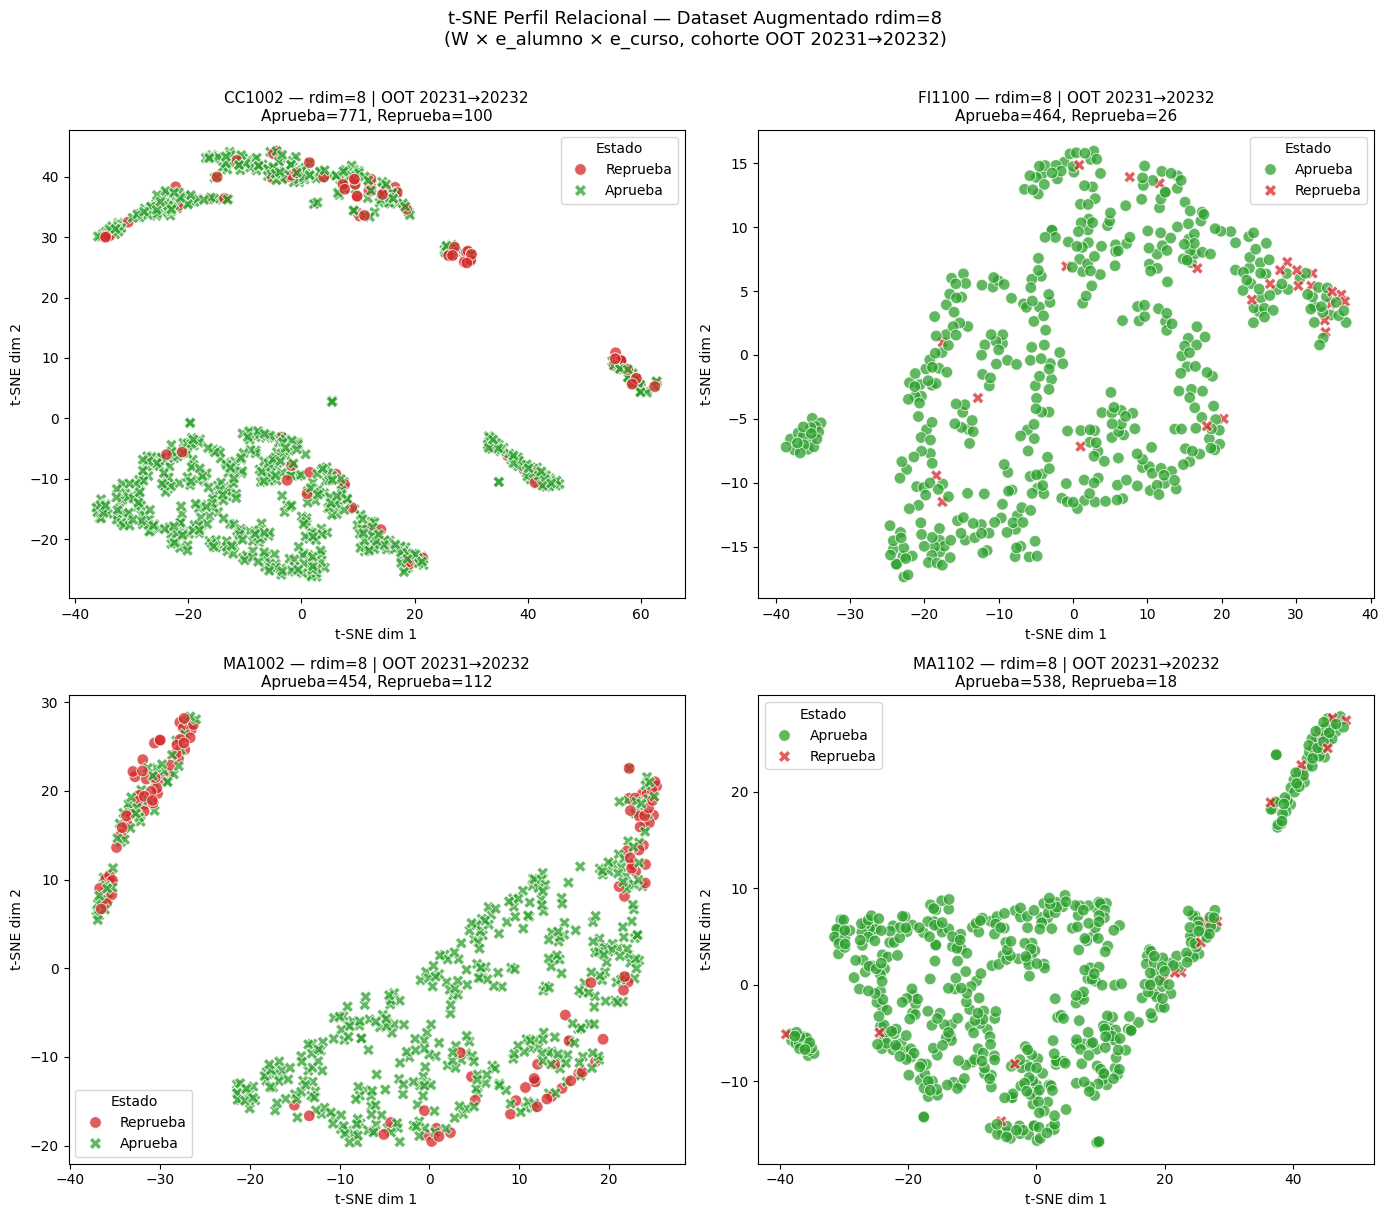

In [8]:
# ============================================================
# 5. t-SNE POR CURSO — COLOREADO POR APRUEBA / REPRUEBA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax_idx, curso_obj in enumerate(CURSOS_A_VISUALIZAR):
    ax = axes[ax_idx]
    
    if curso_obj not in entity_idxs:
        ax.set_title(f"{curso_obj} — no en vocabulario")
        continue
    
    df_curso = df_s2_filt[df_s2_filt["CURSO"] == curso_obj]
    if len(df_curso) < 10:
        ax.set_title(f"{curso_obj} — pocos datos ({len(df_curso)})")
        continue
    
    e_curso = E_tensor[entity_idxs[curso_obj]]  # [edim]
    
    vectores, etiquetas = [], []
    with torch.no_grad():
        for _, row in df_curso.iterrows():
            alumno = row["ID"]
            if alumno not in embeddings_oot:
                continue
            e_h = embeddings_oot[alumno]
            v   = calcular_perfil_relacional(W_tensor, e_h, e_curso)
            vectores.append(v)
            etiquetas.append("Reprueba" if row["relacion"] == "reprueba" else "Aprueba")
    
    if len(vectores) < 5:
        ax.set_title(f"{curso_obj} — vectores insuficientes")
        continue
    
    X_tsne = np.array(vectores, dtype=np.float32)
    perp   = min(30, len(X_tsne) - 1)
    X_emb  = TSNE(
        n_components=2, random_state=SEED,
        perplexity=perp, init="pca", learning_rate=200.0
    ).fit_transform(X_tsne)
    
    df_plot = pd.DataFrame({"x": X_emb[:, 0], "y": X_emb[:, 1], "Estado": etiquetas})
    
    counts = df_plot["Estado"].value_counts()
    n_rep  = counts.get("Reprueba", 0)
    n_apr  = counts.get("Aprueba", 0)
    
    sns.scatterplot(
        data=df_plot, x="x", y="y",
        hue="Estado", style="Estado",
        palette={"Aprueba": "#2ca02c", "Reprueba": "#d62728"},
        s=70, alpha=0.75, ax=ax
    )
    ax.set_title(
        f"{curso_obj} — rdim={RDIM} | OOT {sem_s1_oot}→{sem_s2_oot}\n"
        f"Aprueba={n_apr}, Reprueba={n_rep}",
        fontsize=11
    )
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")

plt.suptitle(
    f"t-SNE Perfil Relacional — Dataset Augmentado rdim={RDIM}\n"
    f"(W × e_alumno × e_curso, cohorte OOT {sem_s1_oot}→{sem_s2_oot})",
    fontsize=13, y=1.01
)
plt.tight_layout()

out_path = OUTPUT_DIR / f"tsne_binario_rdim{RDIM}_{sem_s1_oot}{sem_s2_oot}.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Guardado: {out_path}")
plt.show()

Guardado: C:\Users\LuisPlaza\MEMORIA\tucker_pull\results\tsne_augmentado_rdim8\tsne_notas_rdim8_2023120232.png


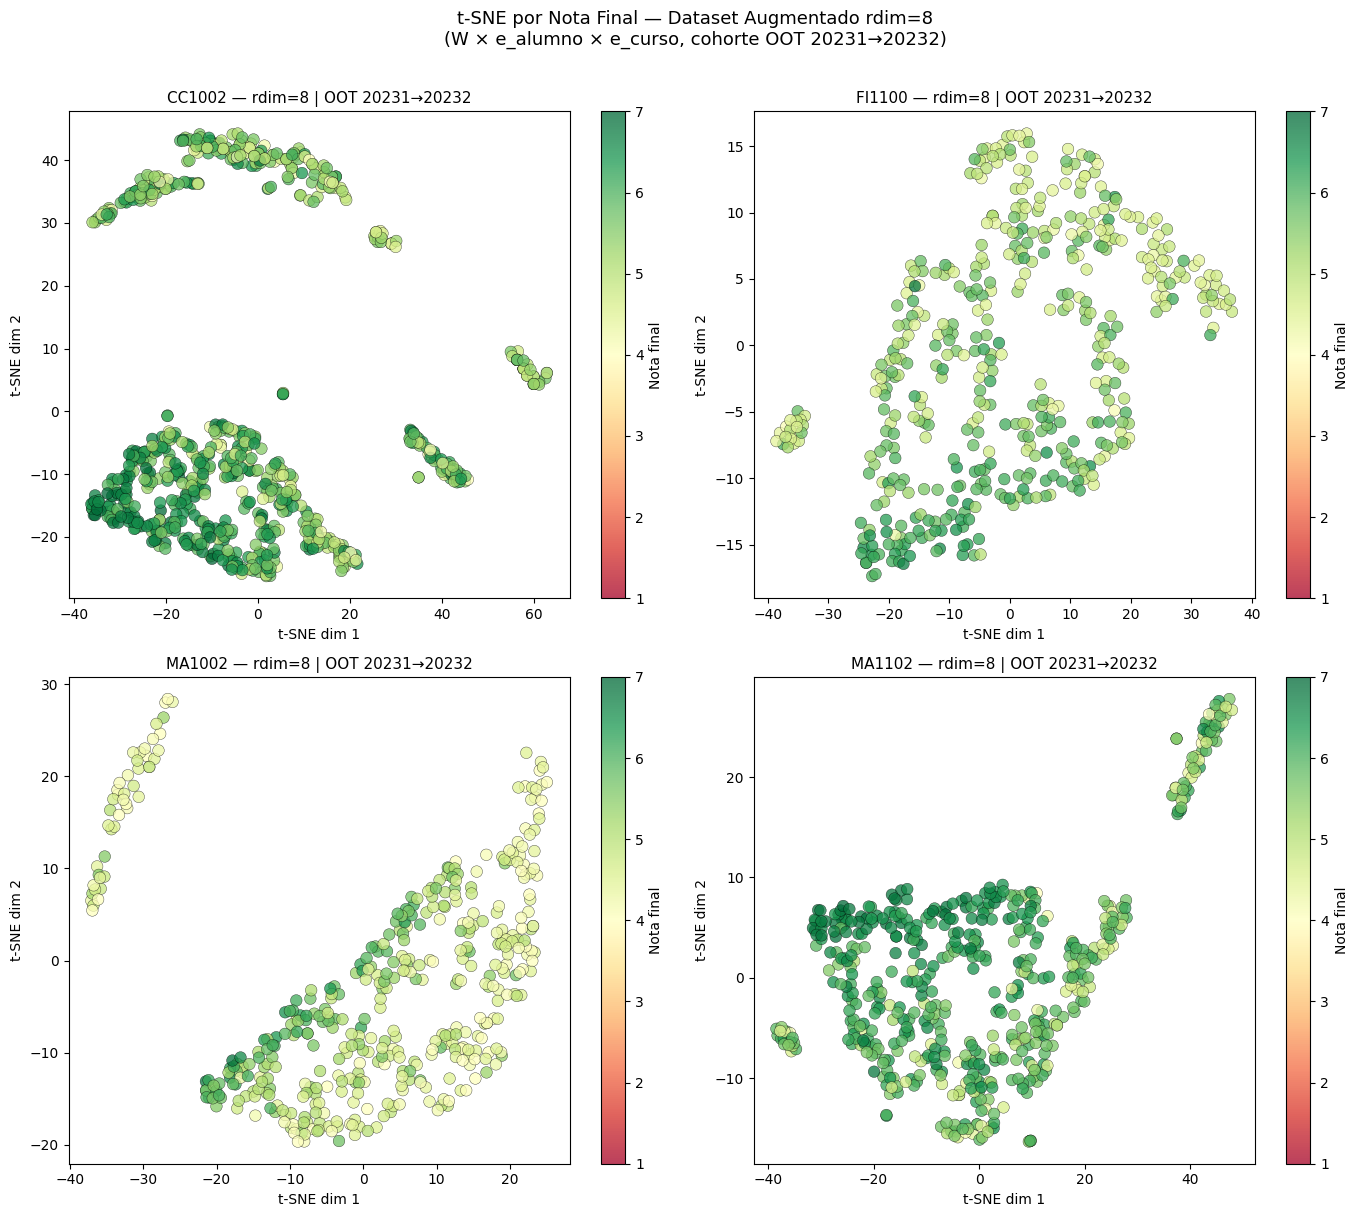

In [9]:
# ============================================================
# 6. t-SNE POR CURSO — COLOREADO POR NOTA (continuo)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax_idx, curso_obj in enumerate(CURSOS_A_VISUALIZAR):
    ax = axes[ax_idx]
    
    if curso_obj not in entity_idxs:
        ax.set_title(f"{curso_obj} — no en vocabulario")
        continue
    
    df_curso = df_s2_filt[df_s2_filt["CURSO"] == curso_obj]
    if len(df_curso) < 10:
        ax.set_title(f"{curso_obj} — pocos datos ({len(df_curso)})")
        continue
    
    e_curso = E_tensor[entity_idxs[curso_obj]]
    
    vectores, notas_vals = [], []
    with torch.no_grad():
        for _, row in df_curso.iterrows():
            alumno = row["ID"]
            if alumno not in embeddings_oot:
                continue
            e_h = embeddings_oot[alumno]
            v   = calcular_perfil_relacional(W_tensor, e_h, e_curso)
            vectores.append(v)
            notas_vals.append(row["nota_num"])
    
    if len(vectores) < 5:
        ax.set_title(f"{curso_obj} — vectores insuficientes")
        continue
    
    X_tsne = np.array(vectores, dtype=np.float32)
    perp   = min(30, len(X_tsne) - 1)
    X_emb  = TSNE(
        n_components=2, random_state=SEED,
        perplexity=perp, init="pca", learning_rate=200.0
    ).fit_transform(X_tsne)
    
    df_plot = pd.DataFrame({"x": X_emb[:, 0], "y": X_emb[:, 1], "Nota": notas_vals})
    
    sc = ax.scatter(
        df_plot["x"], df_plot["y"],
        c=df_plot["Nota"], cmap="RdYlGn",
        vmin=1.0, vmax=7.0,
        s=70, alpha=0.75, edgecolors="k", linewidths=0.3
    )
    plt.colorbar(sc, ax=ax, label="Nota final")
    ax.set_title(
        f"{curso_obj} — rdim={RDIM} | OOT {sem_s1_oot}→{sem_s2_oot}",
        fontsize=11
    )
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")

plt.suptitle(
    f"t-SNE por Nota Final — Dataset Augmentado rdim={RDIM}\n"
    f"(W × e_alumno × e_curso, cohorte OOT {sem_s1_oot}→{sem_s2_oot})",
    fontsize=13, y=1.01
)
plt.tight_layout()

out_path = OUTPUT_DIR / f"tsne_notas_rdim{RDIM}_{sem_s1_oot}{sem_s2_oot}.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Guardado: {out_path}")
plt.show()